# Jurnal Sementara Modul 4

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

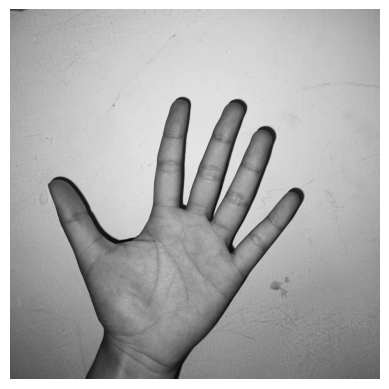

In [117]:
tangan = plt.imread("tangan1.jpeg")
gray = cv2.cvtColor(tangan, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off")

In [118]:
kernel_5x5 = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
])

kernel_3x3 = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

kernel_x = np.array([
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1],
    [1,1,1,1,1]
], dtype=np.uint8)

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

In [119]:
#resize
def resize(img, h_new, w_new):
    h, w = img.shape[:2]
    hasil = np.zeros((h_new, w_new), dtype = np.uint8)
    for i in range(h_new):
        for j in range (w_new):
            x = int(j * w/w_new)
            y = int(i * h/h_new)
            hasil[i,j] = img[y, x]
    return hasil


In [120]:
#tresholding
def tresh(img, nilai):
    h, w = img.shape
    canvas = np.zeros_like(img, dtype = np.uint8)
    for i in range (h):
        for j in range (w):
            if (img[i, j] > nilai):
                canvas[i, j] = 255
            elif(img[i, j] <= nilai):
                canvas[i,j] = 0
    return canvas

In [121]:
#konvolusi
def konvolusi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [122]:
def edge(img, kernelx, kernely):
    gx = konvolusi(img, kernelx)
    gy = konvolusi(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

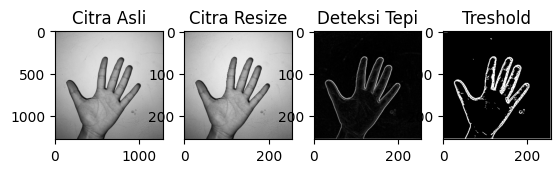

In [123]:
baru = resize(gray, 256, 256)
detektepi = edge(baru, sobelX, sobelY)
treshold = tresh(detektepi, 30)

plt.Figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.imshow(gray, cmap = "gray")
plt.title("Citra Asli")

plt.subplot(1, 4, 2)
plt.imshow(baru, cmap = "gray")
plt.title("Citra Resize")

plt.subplot(1, 4, 3)
plt.imshow(detektepi, cmap = "gray")
plt.title("Deteksi Tepi")

plt.subplot(1, 4, 4)
plt.imshow(treshold, cmap = "gray")
plt.title("Treshold")

plt.show()

In [124]:
# dilasi
def dilasi(img, kernel):
    h, w = img.shape
    k_h, k_w = kernel.shape

    center = k_h // 2
    hasil = np.zeros((h,w))
    for i  in range(center, h - center):
        for j in range(center, w - center):
            if img[i,j] == 255:
                for k in range (k_h):
                    for l in range (k_w):
                        if (kernel[k,l] == 1):
                            hasil [i + k - center, j + l - center] = 255
            else :
                if hasil[i,j] != 255 :
                    hasil[i,j] = 0
    return hasil

In [125]:
#erosi
def erosi(img, kernel) :
    h, w = img.shape
    k_h, k_w = kernel.shape

    center = k_h // 2
    hasil = np.zeros((h,w))
    for i  in range(center, h - center):
        for j in range(center, w - center):
            cocok = True
            for k in range (k_h):
                for l in range (k_w):
                    if kernel[k,l] == 1 and img[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok :
                    break
            if cocok :
                hasil[i,j] = 255
    return hasil

#opening = erosi + dilasi
#closing = dilasi + erosi

In [126]:
#thinning
def thinning(img):
    biner = (img > 0).astype(np.uint8)
    h, w = biner.shape
    changed = True
    
    while changed :
        changed = False
        hapus = []
        #step 1
        for i in range (1, h-1):
            for j in range (1, w-1):
                p1 = biner[i,j]
                if p1 != 1:
                    continue
                p2 = biner[i-1, j]
                p3 = biner[i-1, j+1]
                p4 = biner[i, j+1]
                p5 = biner[i+1, j+1]
                p6 = biner[i+1, j]
                p7 = biner[i+1, j-1]
                p8 = biner[i, j-1]
                p9 = biner[i-1, j-1]

                tetangga = [p2, p3, p4, p5, p6, p7, p8, p9]
                jmlh = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [p2]

                for k in range(8) :
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                
                if (
                    2 <= jmlh <= 6 and
                    transisi == 1 and
                    p2 * p4 * p6 == 0 and
                    p4 * p6 * p8 == 0 
                ) :
                    hapus.append((i,j))
        if hapus :
            changed = True
            for i, j in hapus :
                biner[i,j] = 0
        hapus = []

        #step 2
        for i in range (1, h-1):
            for j in range (1, w-1):
                p1 = biner[i,j]
                if p1 != 1:
                    continue
                p2 = biner[i-1, j]
                p3 = biner[i-1, j+1]
                p4 = biner[i, j+1]
                p5 = biner[i+1, j+1]
                p6 = biner[i+1, j]
                p7 = biner[i+1, j-1]
                p8 = biner[i, j-1]
                p9 = biner[i-1, j-1]

                tetangga = [p2, p3, p4, p5, p6, p7, p8, p9]
                jmlh = np.sum(tetangga)
                transisi = 0
                urutan = tetangga + [p2]

                for k in range(8) :
                    if urutan[k] == 0 and urutan[k+1] == 1:
                        transisi += 1
                
                if (
                    2 <= jmlh <= 6 and
                    transisi == 1 and
                    p2 * p4 * p8 == 0 and
                    p2 * p6 * p8 == 0 
                ) :
                    hapus.append((i,j))
        if hapus :
            changed = True
            for i, j in hapus :
                biner[i,j] = 0

    return biner * 255


In [127]:
#thickening
def thickening(img, kernel, iterasi=1) :
    hasil = img.copy()
    for _ in range (iterasi):
        hasil = dilasi(hasil, kernel)
    return hasil

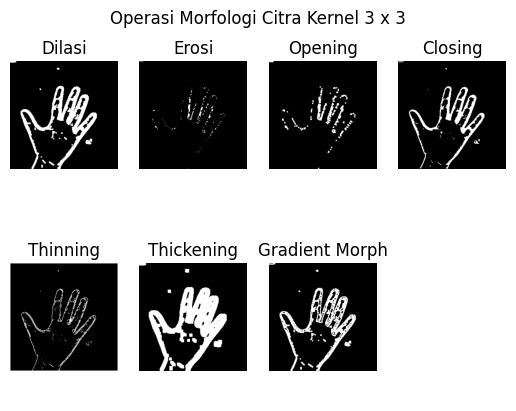

In [128]:
dila = dilasi(treshold, kernel_3x3)
ero = erosi(treshold, kernel_3x3)
open = dilasi(ero, kernel_3x3)
clos = erosi (dila, kernel_3x3)
thin = thinning(treshold)
tick = thickening(treshold, kernel_3x3, 3)
grad = np.clip(dilasi(treshold, kernel_3x3).astype(np.int16) - erosi(treshold, kernel_3x3).astype(np.int16), 0, 255).astype(np.uint8)

plt.Figure(figsize=(15, 15))
plt.title("Operasi Morfologi Citra Kernel 3 x 3")
plt.axis("off")
plt.subplot(2, 4, 1)
plt.imshow(dila, cmap = "gray")
plt.title("Dilasi")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(ero, cmap = "gray")
plt.title("Erosi")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(open, cmap = "gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(clos, cmap = "gray")
plt.title("Closing")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(thin, cmap = "gray")
plt.title("Thinning")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(tick, cmap = "gray")
plt.title("Thickening")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(grad, cmap = "gray")
plt.title("Gradient Morph")
plt.axis("off")

plt.show()

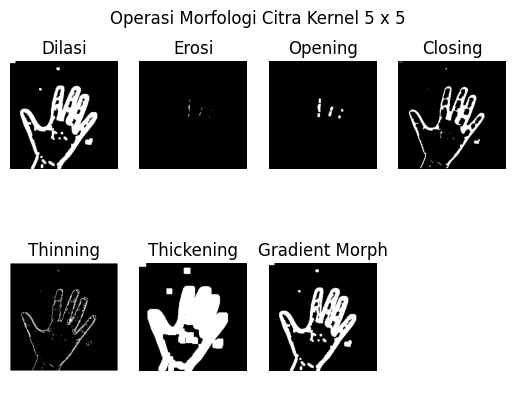

In [129]:
dila1 = dilasi(treshold, kernel_5x5)
ero1 = erosi(treshold, kernel_5x5)
open1 = dilasi(ero1, kernel_5x5)
clos1 = erosi (dila1, kernel_5x5)
thin1 = thinning(treshold)
tick1 = thickening(treshold, kernel_5x5, 3)
grad1 = np.clip(dilasi(treshold, kernel_5x5).astype(np.int16) - erosi(treshold, kernel_5x5).astype(np.int16), 0, 255).astype(np.uint8)

plt.Figure(figsize=(15, 15))
plt.title("Operasi Morfologi Citra Kernel 5 x 5")
plt.axis("off")
plt.subplot(2, 4, 1)
plt.imshow(dila1, cmap = "gray")
plt.title("Dilasi")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(ero1, cmap = "gray")
plt.title("Erosi")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(open1, cmap = "gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(clos1, cmap = "gray")
plt.title("Closing")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(thin1, cmap = "gray")
plt.title("Thinning")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(tick1, cmap = "gray")
plt.title("Thickening")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(grad1, cmap = "gray")
plt.title("Gradient Morph")
plt.axis("off")

plt.show()

## ANALISIS PERBEDAAN CIRA SEBELUM DAN SESUDAH OPERASI MORFOLOGI

citra sebelum dilakukan operasi dilasi, tickening, dan gradient morph dengan sesudahnya memiliki perbedaan yang signifikan di mana garis garis tangan lebih terlihat jelas dan lebih tebal setelah diakukan operasi dilasi. Sedangkan, jika menggunakan operasi erosi dan opening garis tangan menjadi sedikit menghilang dibanding dengan citra asli sebelum dilakukannya proses. Ketika menggunakan closing, citra menjadi lebih jelas terlihat. Namun dengan thinning garis tangan menjadi lebih tipis. 

## ANALISIS CITRA DENGAN KERNEL 3X3 DAN 5X5

Operasi morfologi citra dengan kernel 5x5 menampilkan hasil dengan ketebalan lebih tinggi deibandingkan menggunakan kernel 3x3. Namun, untuk detail dan bentuk objek operasi morfologi citra dengan kernel 3x3 menghasilkan detail tangan dan bentuk objek yang lebih detail dan berbentuk dibanding dengan operasi menggunakan kernel 5x5 serta noise yang dihasilkan pada operasi dengan kernel 5x5 lebih banyak dibanding menggunakan kernel 3x3.

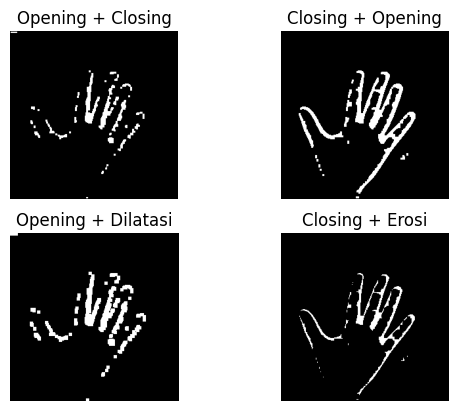

In [130]:
open_dila = dilasi(open, kernel_3x3)
opclos = erosi(open_dila, kernel_3x3)

clos_ero = erosi(clos, kernel_3x3)
closop = dilasi(clos_ero, kernel_3x3)

plt.Figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(opclos, cmap = "gray")
plt.title("Opening + Closing")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(closop, cmap = "gray")
plt.title("Closing + Opening")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(open_dila, cmap = "gray")
plt.title("Opening + Dilatasi")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(clos_ero, cmap = "gray")
plt.title("Closing + Erosi")
plt.axis("off")

plt.show()

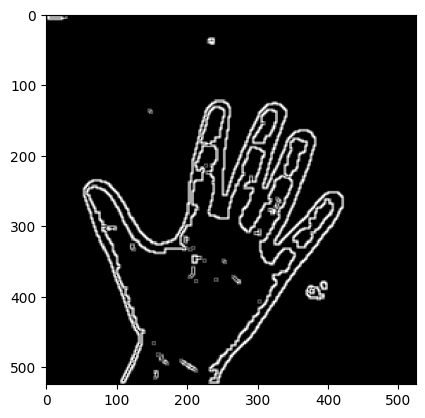

In [131]:
#explore mandiri
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = [0] * (size * size)
                    for r in range(size):
                        for c in range(size):
                            values[r * size + c] = int(region[r, c])

                    n = size * size
                    for x in range(n - 1):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]

                    canvas[i, j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas



cb = edge(clos, sobelX, sobelY)
cb2 = resize(cb, 525, 525)
plt.imshow(cb2, cmap = "gray")